In [19]:
print('Radha!')

Radha!


In [20]:
import os
from typing import TypedDict, Literal
from pydantic import BaseModel, Field
from dotenv import load_dotenv

from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import StateGraph, START, END

load_dotenv()


True

In [21]:
# ============================================================
# 1. CONSTANTS & SAFETY LIMITS
# ============================================================
MAX_REVISIONS = 3  # Hard limit on revision loop count

# Capping max_tokens stops long-winded output and reduces token consumption
llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0.7,
    max_tokens=500
)



In [22]:
# ============================================================
# 2. STRUCTURED OUTPUT SCHEMA
# ============================================================
class SupervisorDecision(BaseModel):
    """Structured decision schema for supervisor routing."""
    next_agent: Literal["writer", "reviewer", "final", "end"] = Field(
        description="The next agent to execute, or 'end' if processing is completed."
    )
    reasoning: str = Field(
        description="Brief explanation of why this agent was selected."
    )

supervisor_llm = llm.with_structured_output(SupervisorDecision)


In [23]:
# ============================================================
# 3. SHARED STATE
# ============================================================
class ContentState(TypedDict):
    topic: str
    draft: str
    review: str
    review_status: str  # "APPROVED" or "NEEDS_REVISION"
    final_post: str
    next_agent: str
    revision_count: int


In [24]:
# ============================================================
# 4. WORKER AGENTS
# ============================================================
def writer_agent(state: ContentState) -> dict:
    """Drafts or rewrites content based on reviewer feedback."""
    feedback_context = ""
    if state.get("review") and state.get("review_status") == "NEEDS_REVISION":
        feedback_context = f"\n\nAddress the following feedback:\n{state['review']}"

    prompt = f"""You are a professional LinkedIn content writer.
Topic: {state['topic']}{feedback_context}

Requirements:
- Strong 2-line hook
- Clean formatting with short paragraphs
- Technical value without excessive jargon
- Clear Call to Action (CTA)
"""
    response = llm.invoke([
        SystemMessage(content="You generate engaging technical LinkedIn posts."),
        HumanMessage(content=prompt)
    ])
    
    current_revisions = state.get("revision_count", 0)
    
    # Clears previous review state so the supervisor routes back to reviewer
    return {
        "draft": str(response.content),
        "review": "",
        "review_status": "",
        "revision_count": current_revisions + 1
    }


def reviewer_agent(state: ContentState) -> dict:
    """Evaluates the draft and returns structured status + feedback."""
    prompt = f"""You are an editorial reviewer.
Review this draft on topic: "{state['topic']}"

DRAFT:
{state['draft']}

Provide evaluation in exact format:
STATUS: [APPROVED or NEEDS_REVISION]
FEEDBACK: [1-2 concise actionable points]
"""
    response = llm.invoke([
        SystemMessage(content="You review drafts objectively."),
        HumanMessage(content=prompt)
    ])
    
    content = str(response.content)
    status = "APPROVED" if "STATUS: APPROVED" in content.upper() else "NEEDS_REVISION"
    
    return {
        "review": content,
        "review_status": status
    }


def final_agent(state: ContentState) -> dict:
    """Formats and polishes the approved post into its final form."""
    prompt = f"""You are a professional editor.
Polish the following post for immediate publication:

DRAFT:
{state['draft']}

Return ONLY the polished LinkedIn post content without commentary.
"""
    response = llm.invoke([
        SystemMessage(content="You format finalized copy."),
        HumanMessage(content=prompt)
    ])
    
    return {"final_post": str(response.content)}


In [25]:
# ============================================================
# 5. SUPERVISOR & ROUTING (SAFETY ENFORCED)
# ============================================================
def supervisor(state: ContentState) -> dict:
    """Evaluates state and controls workflow progression with safety boundaries."""
    
    # 1. IMMEDIATE EXIT GUARD: Terminate if post is finished
    if state.get("final_post"):
        return {"next_agent": "end"}

    # 2. REVISION LIMIT GUARD: Stop infinite revision loops at MAX_REVISIONS
    if state.get("revision_count", 0) >= MAX_REVISIONS and state.get("draft"):
        return {"next_agent": "final"}

    system_prompt = """You are the AI Workflow Supervisor.
Choose the next step based strictly on state:

- 'writer': If no draft exists OR if review_status is 'NEEDS_REVISION'.
- 'reviewer': If a draft exists AND review_status is empty/cleared.
- 'final': If review_status is 'APPROVED'.
- 'end': If final_post is complete.
"""

    state_summary = f"""State Summary:
- Has Draft: {bool(state.get('draft'))}
- Review Status: '{state.get('review_status', '')}'
- Has Final Post: {bool(state.get('final_post'))}
- Current Revision Count: {state.get('revision_count', 0)} / {MAX_REVISIONS}
"""

    decision: SupervisorDecision = supervisor_llm.invoke([
        SystemMessage(content=system_prompt),
        HumanMessage(content=state_summary)
    ])
    
    return {"next_agent": decision.next_agent}


def route_to_agent(state: ContentState) -> Literal["writer", "reviewer", "final", "end"]:
    """Conditional router function."""
    return state["next_agent"]



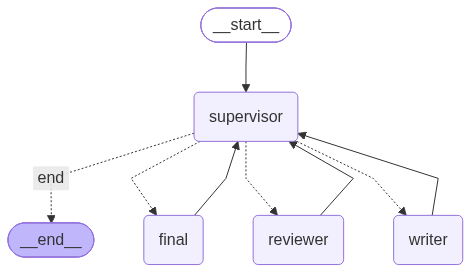

In [26]:
# ============================================================
# 6. GRAPH BUILD
# ============================================================
builder = StateGraph(ContentState)

builder.add_node("supervisor", supervisor)
builder.add_node("writer", writer_agent)
builder.add_node("reviewer", reviewer_agent)
builder.add_node("final", final_agent)

builder.add_edge(START, "supervisor")

builder.add_conditional_edges(
    "supervisor",
    route_to_agent,
    {
        "writer": "writer",
        "reviewer": "reviewer",
        "final": "final",
        "end": END
    }
)

builder.add_edge("writer", "supervisor")
builder.add_edge("reviewer", "supervisor")
builder.add_edge("final", "supervisor")

graph = builder.compile()
graph

In [27]:
# ============================================================
# 7. SAFE EXECUTION (Jupyter / .ipynb)
# ============================================================

initial_state = {
    "topic": "Why Multi-Agent LangGraph Workflows Beat Single Prompt Chains",
    "draft": "",
    "review": "",
    "review_status": "",
    "final_post": "",
    "next_agent": "",
    "revision_count": 0
}

print("🚀 Starting Multi-Agent System with Safety Controls...\n")

# recursion_limit: 8 serves as a circuit breaker against unforeseen loops
config = {"recursion_limit": 8}

try:
    for event in graph.stream(initial_state, config=config):
        for node_name, state_update in event.items():
            print(f"--- Executed Node: {node_name} ---")
            if "next_agent" in state_update:
                print(f"Supervisor Decision -> {state_update['next_agent']}")
            elif "review_status" in state_update:
                print(f"Review Status -> {state_update['review_status']}")
            elif "revision_count" in state_update:
                print(f"Revision Count -> {state_update['revision_count']}")
            print()

    # Fetch completed result
    final_result = graph.invoke(initial_state, config=config)
    
    print("\n" + "="*20 + " PUBLISHABLE OUTPUT " + "="*20 + "\n")
    print(final_result.get("final_post", "No output generated."))
    print("\n" + "="*54)

except Exception as e:
    print(f"Workflow stopped safely: {e}")

🚀 Starting Multi-Agent System with Safety Controls...

--- Executed Node: supervisor ---
Supervisor Decision -> writer

--- Executed Node: writer ---
Review Status -> 

--- Executed Node: supervisor ---
Supervisor Decision -> reviewer

--- Executed Node: reviewer ---
Review Status -> APPROVED

--- Executed Node: supervisor ---
Supervisor Decision -> final

--- Executed Node: final ---

--- Executed Node: supervisor ---
Supervisor Decision -> end


==================== PUBLISHABLE OUTPUT ====================

🚀 **Unlocking the Future of AI: Multi-Agent LangGraph Workflows vs. Single Prompt Chains!** 🌐

In today's fast-paced tech landscape, efficiency and adaptability are paramount. Multi-Agent LangGraph workflows provide a dynamic advantage over traditional single prompt chains, revolutionizing our approach to problem-solving in AI.

**Why Choose Multi-Agent LangGraph?**

1. **Parallel Processing Power**: Unlike single prompt chains that operate sequentially, multi-agent systems can man